In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

In [2]:
os.chdir("/Users/kaiping/Desktop/olist_project/data/processed") 
os.getcwd()

'/Users/kaiping/Desktop/olist_project/data/processed'

In [3]:
# 載入資料
df = pd.read_csv("abt_2nd_purchase_v2.csv")
df.head()

,customer_unique_id,first_purchase_ts,delivery_days_mean,first_event_review_score_mean,late_flag,has_review,customer_state,first_item_cnt,first_purchase_gmv,purchase_2nd_within_90d
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,6.411111,5.0,0,1,SP,1,129.90,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,3.285417,4.0,0,1,SP,1,18.90,0
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,25.731250,3.0,0,1,SC,1,69.00,0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,20.037500,4.0,0,1,PA,1,25.99,0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,13.140972,5.0,0,1,SP,1,180.00,0


In [4]:
# 檢查資料
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75318 entries, 0 to 75317
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_unique_id             75318 non-null  object 
 1   first_purchase_ts              75318 non-null  object 
 2   delivery_days_mean             75318 non-null  float64
 3   first_event_review_score_mean  75318 non-null  float64
 4   late_flag                      75318 non-null  int64  
 5   has_review                     75318 non-null  int64  
 6   customer_state                 75318 non-null  object 
 7   first_item_cnt                 75318 non-null  int64  
 8   first_purchase_gmv             75318 non-null  float64
 9   purchase_2nd_within_90d        75318 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 5.7+ MB


In [5]:
df.isna().sum()

customer_unique_id               0
first_purchase_ts                0
delivery_days_mean               0
first_event_review_score_mean    0
late_flag                        0
has_review                       0
customer_state                   0
first_item_cnt                   0
first_purchase_gmv               0
purchase_2nd_within_90d          0
dtype: int64

In [6]:
df["purchase_2nd_within_90d"].value_counts(normalize=True)

purchase_2nd_within_90d
0    0.98517
1    0.01483
Name: proportion, dtype: float64

In [7]:
# 時間欄位轉換
df["first_purchase_ts"] = pd.to_datetime(df["first_purchase_ts"])

df = df.sort_values("first_purchase_ts").copy()

In [8]:
# # 先依首購時間排序
df = (df.sort_values("first_purchase_ts").copy())

In [9]:
# 建立 X / y 
target = "purchase_2nd_within_90d"

features = [
    "delivery_days_mean",
    "first_event_review_score_mean",
    "late_flag",
    "has_review",
    "customer_state",
    "first_item_cnt",
    "first_purchase_gmv"
]

X = df[features].copy()
y = df[target].copy()

In [10]:
# 時間切分 Train / Test
# 前面 80% 時間較早的首購顧客 → train
# 後面 20% 時間較晚的首購顧客 → test
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[features].copy()
y_train = train_df[target].copy()

X_test = test_df[features].copy()
y_test = test_df[target].copy()

print("Train size:", len(train_df))
print("Test size:", len(test_df))

print("\nTrain label rate:")
print(y_train.value_counts(normalize=True))

print("\nTest label rate:")
print(y_test.value_counts(normalize=True))

Train size: 60254
Test size: 15064

Train label rate:
purchase_2nd_within_90d
0    0.985428
1    0.014572
Name: proportion, dtype: float64

Test label rate:
purchase_2nd_within_90d
0    0.984134
1    0.015866
Name: proportion, dtype: float64


In [11]:
# 建立 Preprocessing Pipeline
numeric_features = [
    "delivery_days_mean",
    "first_event_review_score_mean"
]

binary_features = [
    "late_flag",
    "has_review"
]

categorical_features = [
    "customer_state"
]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# state one-hot編碼
categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", "passthrough", binary_features)
    ]
)

In [12]:
# 建立 Logistic Regression Model

In [13]:
class_weight="balanced" # 因為label 非常不平衡，所以先使用


log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

In [14]:
log_reg_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [15]:
y_pred = log_reg_model.predict(X_test)
y_proba = log_reg_model.predict_proba(X_test)[:, 1]

In [16]:


metrics_result = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba)
}

metrics_result

{'accuracy': 0.360262878385555,
 'precision': 0.017556468172484598,
 'recall': 0.7154811715481172,
 'f1': 0.034271971139392725,
 'roc_auc': 0.5609710217530887,
 'pr_auc': 0.020266904594742473}

In [17]:
# Classification Report
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.99      0.35      0.52     14825
           1       0.02      0.72      0.03       239

    accuracy                           0.36     15064
   macro avg       0.50      0.54      0.28     15064
weighted avg       0.97      0.36      0.51     15064



In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
)

cm_df

,Pred 0,Pred 1
Actual 0,5256,9569
Actual 1,68,171


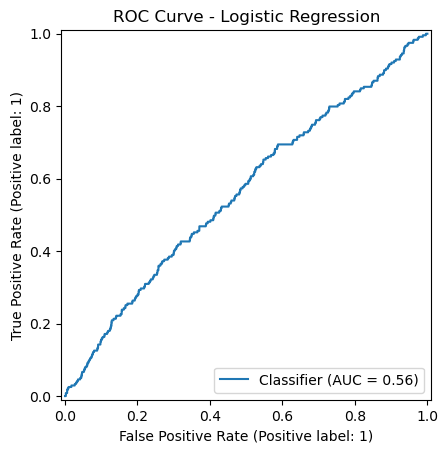

In [19]:
# ROC Curve

RocCurveDisplay.from_predictions(y_test, y_proba)

plt.title("ROC Curve - Logistic Regression")
plt.show()

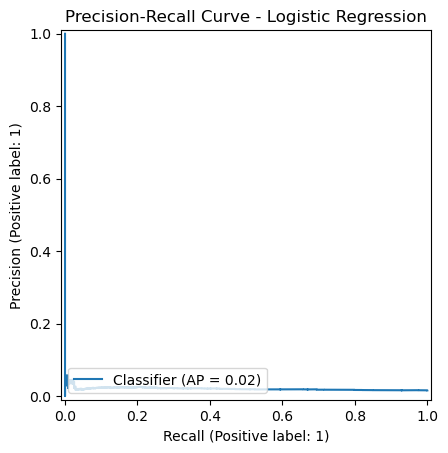

In [20]:
# Precision-Recall Curve


PrecisionRecallDisplay.from_predictions(y_test, y_proba)

plt.title("Precision-Recall Curve - Logistic Regression")
plt.show()

### 計算Top-10 lift

In [21]:
# 1. 取得 test set 預測機率
y_test_prob = log_reg_model.predict_proba(X_test)[:, 1]

# 2. 建立結果表
lift_df = test_df.copy()
lift_df["y_true"] = y_test.values
lift_df["y_prob"] = y_test_prob

# 3. 依照預測機率由高到低排序
lift_df = lift_df.sort_values("y_prob", ascending=False).reset_index(drop=True)

# 4. 取 Top 10%
top_pct = 0.10
top_n = int(len(lift_df) * top_pct)

top10_df = lift_df.iloc[:top_n].copy()

# 5. 計算整體正樣本率與 Top 10% 正樣本率
overall_rate = lift_df["y_true"].mean()
top10_rate = top10_df["y_true"].mean()

# 6. 計算 Top 10% Lift
top10_lift = top10_rate / overall_rate

print("Test overall positive rate:", round(overall_rate, 4))
print("Top 10% positive rate:", round(top10_rate, 4))
print("Top 10% Lift:", round(top10_lift, 2))
print("Top 10% sample size:", top_n)
print("Top 10% actual positives:", int(top10_df["y_true"].sum()))

Test overall positive rate: 0.0159
Top 10% positive rate: 0.0239
Top 10% Lift: 1.51
Top 10% sample size: 1506
Top 10% actual positives: 36
